In [1]:
import torch
import numpy as np
from omegaconf import OmegaConf
from functools import partial
import gymnasium as gym
import matplotlib.pyplot as plt
import re
from pathlib import Path
from tqdm.notebook import tqdm

import time

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest
from bbrl.agents import Agent, Agents, TemporalAgent
from bbrl.agents.gymnasium import ParallelGymAgent, make_env
from bbrl.workspace import Workspace
from bbrl.utils.replay_buffer import ReplayBuffer

import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3, OfflineTD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import (
    run_dqn,
    run_ddpg,
    run_td3,
)
from pmind.replay import (
    collect_policy_transitions,
    collect_uniform_transitions,
    mix_transitions,
    test_rb_compositions,
)

from pmind.visualization import plot_perf_vs_rb_composition_from_dict

from pmind.config.loader import load_config

bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401
Using Python 3.10.18 environment at: /Users/vlad/Documents/University/Master-MIND/projet-mind/.venv


In [ ]:
ENV_NAMES = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    "LunarLanderContinuous-v3",
)
PROPORTIONS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
EVAL_INTERVAL = 100

In [196]:
import pathlib, glob

all_performances = {}
for env_name in ENV_NAMES:
    best_performance = -np.inf
    all_performances[env_name] = {}
    best_path = None 
    for best_path in glob.glob(f"all-run-{env_name}-best-*"):
        curr_performance = float(best_path.split("-best-")[1])
        if curr_performance > best_performance:
            best_performance = curr_performance
            all_performances[env_name][best_performance] = torch.load(best_path, weights_only=False)
    print(f"Best performance for {env_name}:\n    {best_performance}")
    
    print(f"Intermediate performances:")
    for intermediate_path in glob.glob(f"all-run-{env_name}-intermediate-*"):
        exploit_performance = float(intermediate_path.split("-intermediate-")[1])
        print(f"    {exploit_performance}")
        all_performances[env_name][exploit_performance] = torch.load(intermediate_path, weights_only=False)

Best performance for CartPoleContinuous-v1:
    500.0
Intermediate performances:
    500.0
    129.0
    439.0
    293.0
Best performance for Pendulum-v1:
    -145.0
Intermediate performances:
    -479.0
    -233.0
    -958.0
    -742.0
Best performance for MountainCarContinuous-v0:
    -inf
Intermediate performances:
Best performance for LunarLanderContinuous-v3:
    -inf
Intermediate performances:


In [330]:
def smooth(x, sigma, mode = "gaussian"):
    radius = int(3 * sigma)
    if mode == "gaussian":
        t = np.arange(-radius, radius + 1)
        kernel = np.exp(-(t**2) / (2 * sigma**2))
        kernel /= kernel.sum()
        return np.convolve(x, kernel, mode="valid")
    elif mode == "max":
        window = 2 * radius + 1
        return np.array([
            np.max(x[i:i+window])
            for i in range(len(x) - window + 1)
        ])
    else:
        raise ValueError
        

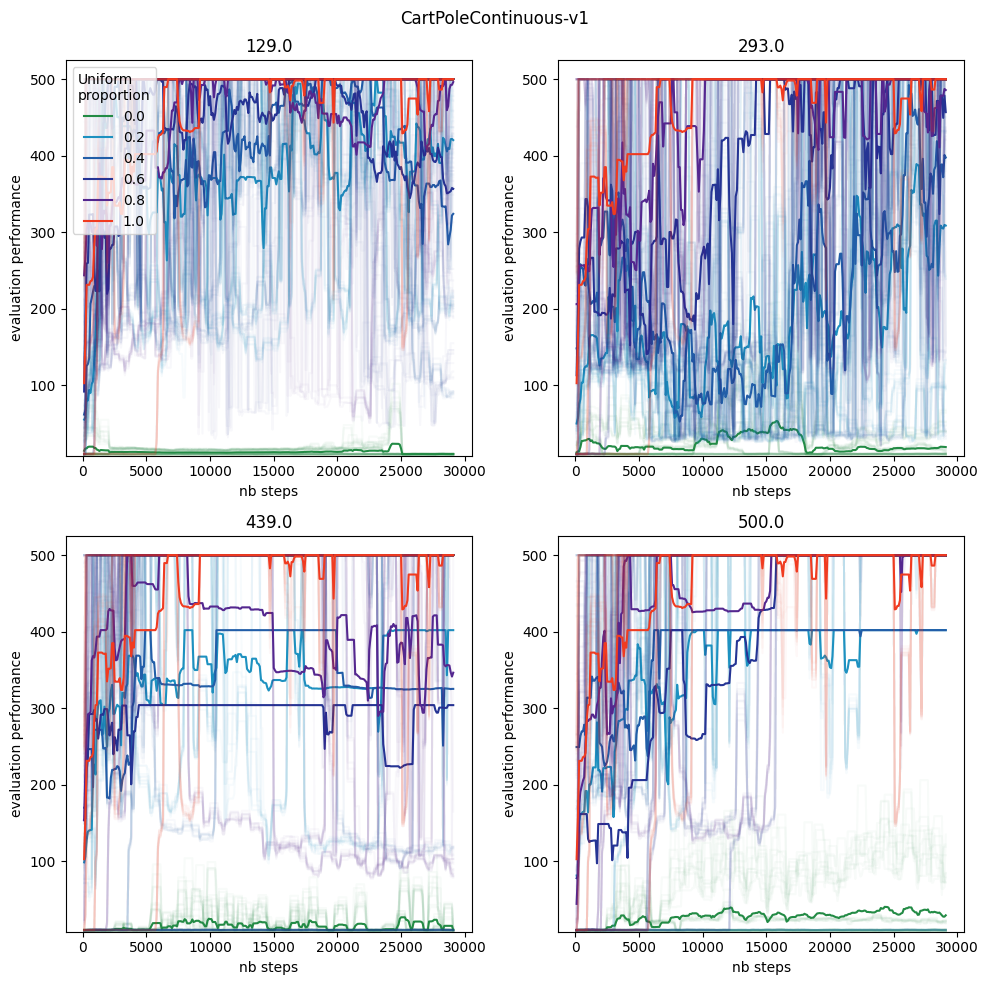

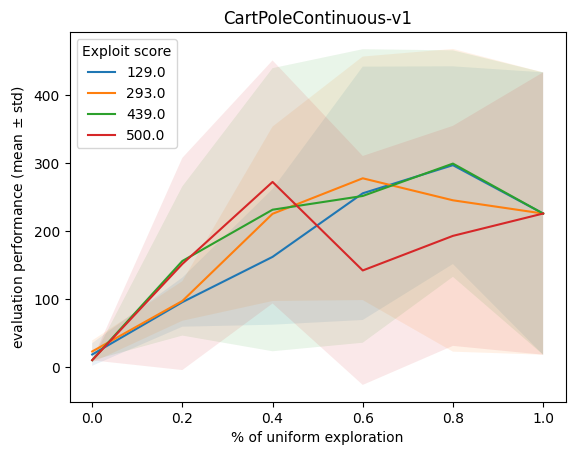

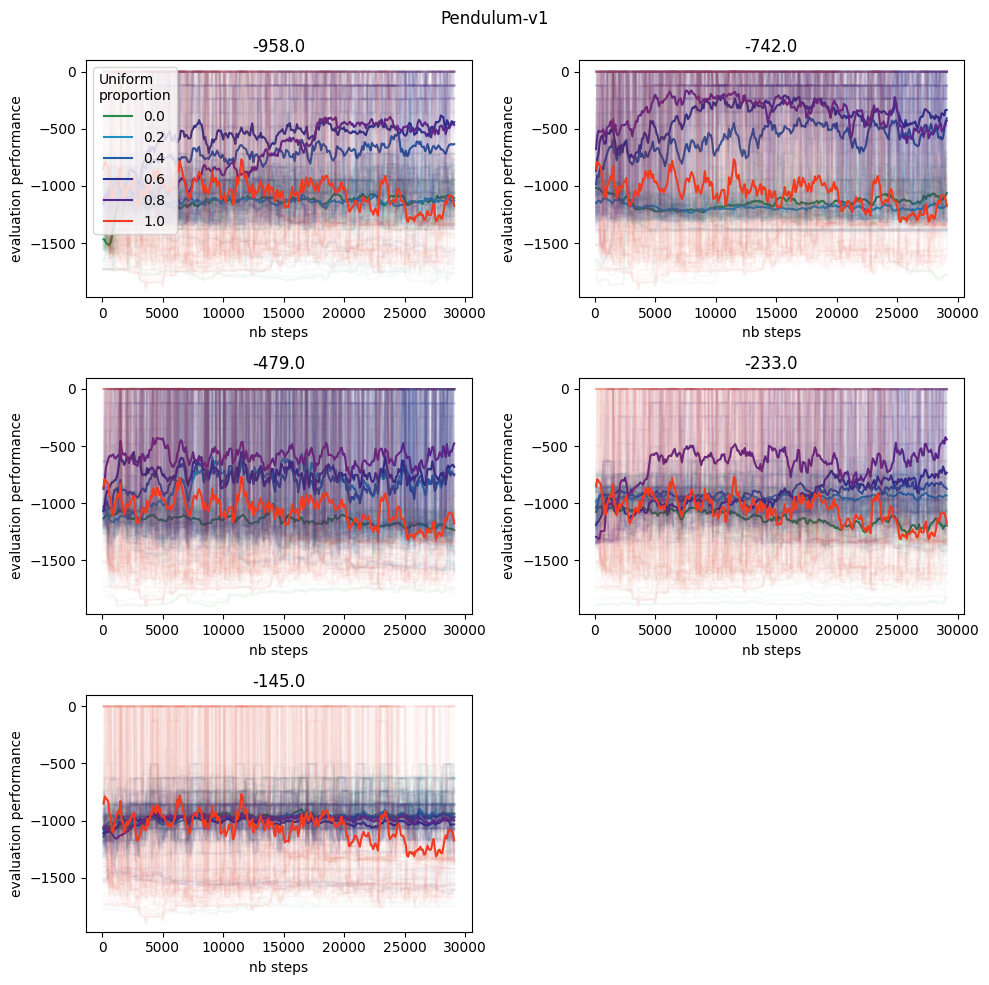

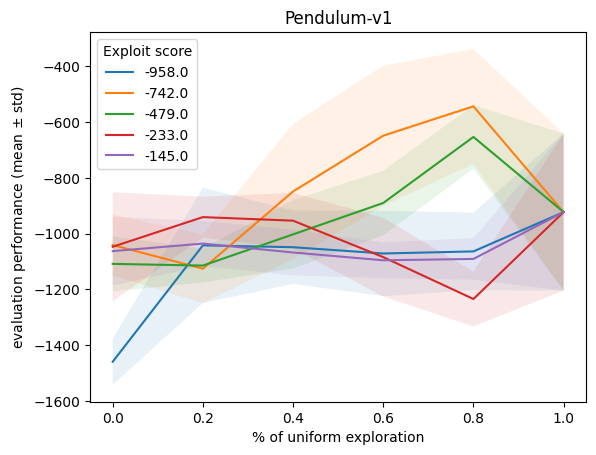

In [339]:
colors = [
"#238b45",  
"#1d91c0",  
"#225ea8",  
"#253494",  
"#54278f",  
"#f03b20"   
]

SMOOTH_SIGMA = 1
SMOOTH_MODE = "max"
PLOT_ALL_CURVES = True#False
LAST_N = 10

last_performances = {}
std_last_performances = {}

for env_name in ENV_NAMES:
    if not all_performances[env_name]:
        continue
    
    last_performances[env_name] = {}
    std_last_performances[env_name] = {}
    
    # Learning curves ==========================
    nrows = 2
    fig, axes = plt.subplots(int(np.ceil(len(all_performances[env_name])/nrows)), nrows, figsize=(10,10))
    axes = axes.flatten()
    for i_score, score in enumerate(sorted(all_performances[env_name])):
        last_performances[env_name][score] = np.zeros(len(PROPORTIONS))
        std_last_performances[env_name][score] = np.zeros(len(PROPORTIONS))
        # List by proportion of arrays EVAL_NUM x ENV x SEED
        performances = all_performances[env_name][score] 
        for i_prop, proportion in enumerate(PROPORTIONS):
            nb_evals, nb_envs, nb_seeds = performances[0].shape
            learning_curves = np.empty( (nb_evals - 2*int(3 * SMOOTH_SIGMA), nb_envs,nb_seeds) )
            for i_env in range(performances[0].shape[1]):
                for i_seed in range(performances[0].shape[2]):
                    learning_curve = performances[i_prop][:,i_env,i_seed]
                    learning_curve = smooth(learning_curve, sigma=SMOOTH_SIGMA, mode=SMOOTH_MODE)
                    learning_curves[:,i_env,i_seed] = learning_curve
                    label = proportion if i_seed == 0 and i_env == 0 else None
                    if PLOT_ALL_CURVES:
                        axes[i_score].plot((np.arange(len(learning_curve))+1)*EVAL_INTERVAL,learning_curve, color = colors[i_prop], alpha=0.03) # label = label
            # NOTE: Choose aggregation: first on ENV and then on SEED dimension
            aggregated_learning_curves = learning_curves.mean(1).mean(1)
            std_learning_curves = learning_curves.mean(1).std(1)
            
            last_performances[env_name][score][i_prop] = aggregated_learning_curves[:LAST_N].mean()
            std_last_performances[env_name][score][i_prop]= std_learning_curves[:LAST_N].mean() # TODO: better std pooling
            
            axes[i_score].plot((np.arange(len(learning_curves))+1)*EVAL_INTERVAL, aggregated_learning_curves, color = colors[i_prop], label=proportion, alpha=1)
            
            min_perf, max_perf = performances[i_prop].min(), performances[i_prop].max()
            axes[i_score].set_ylim([ min_perf, max_perf + 0.05 * (max_perf - min_perf) ])
        axes[i_score].set_title(f"{score}")
        axes[i_score].set_ylabel("evaluation performance")
        axes[i_score].set_xlabel("nb steps")
    for ax in axes[i_score+1:]:
        fig.delaxes(ax)
    axes[0].legend(title="Uniform\nproportion", loc = "upper left")
    fig.suptitle(f"{env_name}")
    plt.tight_layout()
    plt.show()
    
    # Performance ~ RB composition =====================================

    for i_score, score in enumerate(sorted(all_performances[env_name])):
        performances =  all_performances[env_name][score]
        means = last_performances[env_name][score]
        stds = std_last_performances[env_name][score]
        plt.plot(PROPORTIONS, means, label=score)
        plt.fill_between(
            PROPORTIONS,
            means - stds,
            means + stds,
            alpha=0.1,
        )

    plt.title(f"{env_name}")
    plt.xlabel("% of uniform exploration")
    plt.ylabel("evaluation performance (mean $\\pm$ std)")
    plt.legend(title="Exploit score")
    plt.show()
